# load & inspect

In [1]:
import pandas as pd 
df = pd.read_csv("data/house_prices.csv")
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [2]:
df.shape 

(187531, 21)

In [3]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.describe() 

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

* there are 187531 rows and 21 columns in this dataset.
* there are only 4 columns that are numeric and the rest is string.
* columns[Plot Area, Dimensions, Society, Super Area, Car Parking] have missing values for more than half of the rows.

# Data Cleaning

### converting price from text to numeric

In [6]:
def parse_amount(value):
    if not isinstance(value, str):
        return None

    value=value.strip().lower()

    if value=="call for price":
        return None

    try:
        if "lac" in value:
            return float(value.replace("lac", "").strip()) * 100000

        if "cr" in value:
            return float(value.replace("cr", "").strip()) * 10000000

        return float(value.replace(",", ""))

    except ValueError:
        return None

In [7]:
df["price_clean"]=df["Amount(in rupees)"].apply(parse_amount)

In [8]:
df=df.dropna(subset=["price_clean"])

### keeping only the top 50 locations and grouping the rest into 'other'

In [9]:
df['location'].value_counts()

location
new-delhi      24945
bangalore      23262
kolkata        21605
gurgaon        18846
ahmedabad      12614
               ...  
palakkad          30
solapur           30
nellore           29
pondicherry       29
madurai           26
Name: count, Length: 81, dtype: int64

In [10]:
topLocations=df["location"].value_counts().head(50).index

df["location_top"]=df["location"].apply(
    lambda x: x if x in topLocations else "Other"
)

### converting carpet area from text to numeric

In [11]:
df['Carpet Area'].value_counts()

Carpet Area
1000 sqft    5223
900 sqft     4616
1300 sqft    3446
1600 sqft    2737
600 sqft     2210
             ... 
2340 sqft       1
1526 sqft       1
1634 sqft       1
164 sqyrd       1
136 sqft        1
Name: count, Length: 2699, dtype: int64

In [12]:
def parse_area(value):
    if not isinstance(value, str):
        return None

    value=value.strip().lower()

    try:
        if "sqm" in value:
            return float(value.replace("sqm", "").strip()) * 10.764

        if "sqft" in value:
            return float(value.replace("sqft", "").strip())

        return float(value)

    except ValueError:
        return None

In [13]:
df["carpet_area_sqft"]=df["Carpet Area"].apply(parse_area)

### extracting the floor number from text

In [14]:
df["Floor"].value_counts().head(20)

Floor
1 out of 4          11801
2 out of 4          11437
3 out of 4           7804
1 out of 3           6934
2 out of 3           5868
4 out of 4           5814
3 out of 3           4405
2 out of 5           4331
4 out of 5           3723
3 out of 6           3579
3 out of 5           3360
2 out of 2           3350
1 out of 5           3319
1 out of 2           2829
Ground out of 4      2778
5 out of 5           2405
8 out of 10          2381
Ground out of 10     2154
3 out of 10          1967
4 out of 8           1888
Name: count, dtype: int64

In [15]:
floor_clean=df["Floor"].astype(str).str.split(" out of ").str[0]

In [16]:
floor_clean=floor_clean.replace({
    "Ground": 0,
    "Upper Basement": -1,
    "Lower Basement": -2
})

In [17]:
df["floor_num"]=pd.to_numeric(floor_clean, errors="coerce")

In [18]:
df['floor_num'].isnull().sum()

np.int64(6949)

In [19]:
df["floor_num"]=df["floor_num"].fillna(df["floor_num"].median())

### handling missing values

In [20]:
df["Transaction"].value_counts(dropna=False)

Transaction
Resale          135630
New Property     41445
Other              703
NaN                 67
Rent/Lease           2
Name: count, dtype: int64

In [21]:
df["Transaction"]=df["Transaction"].fillna("Unknown")

In [22]:
df["Furnishing"].value_counts(dropna=False)

Furnishing
Semi-Furnished    82868
Unfurnished       73491
Furnished         19421
NaN                2067
Name: count, dtype: int64

In [23]:
df["Furnishing"]=df["Furnishing"].fillna("Unknown")

In [24]:
df["facing"].value_counts(dropna=False)

facing
NaN             65736
East            52244
North - East    23349
North           15302
West             8474
South            4316
North - West     3803
South - East     2571
South -West      2052
Name: count, dtype: int64

In [25]:
df["facing"]=df["facing"].fillna("Unknown")

### converting bathroom values to numeric and handling missing values

In [26]:
df["Bathroom"].value_counts()

Bathroom
2       88999
3       54187
1       15509
4       14826
5        3281
6         187
7          32
> 10       29
8          14
10         12
9          11
Name: count, dtype: int64

In [27]:
df["Bathroom"]=df["Bathroom"].replace("> 10", 10)

In [28]:
df["Bathroom"]=pd.to_numeric(df["Bathroom"], errors="coerce")

In [29]:
df['Bathroom'].isnull().sum()

np.int64(760)

In [30]:
df["Bathroom"]=df["Bathroom"].fillna(df["Bathroom"].median())

### converting balcony values to numeric and handling missing values

In [31]:
df['Balcony'].value_counts()

Balcony
2       50311
1       45145
3       24958
4        9275
5         814
6         127
> 10       16
7          14
10         13
8          13
9           2
Name: count, dtype: int64

In [32]:
df["Balcony"]=df["Balcony"].replace("> 10", 10)

In [33]:
df["Balcony"]=pd.to_numeric(df["Balcony"], errors="coerce")

In [34]:
df['Balcony'].isnull().sum()

np.int64(47159)

In [35]:
df["Balcony"]=df["Balcony"].fillna(df["Balcony"].median())

### handling missing values in ownership

In [36]:
df["Ownership"].value_counts(dropna=False)

Ownership
Freehold                106411
NaN                      61925
Leasehold                 5149
Co-operative Society      3349
Power Of Attorney         1013
Name: count, dtype: int64

In [37]:
df["Ownership"]=df["Ownership"].fillna("Unknown")

In [38]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area,price_clean,location_top,carpet_area_sqft,floor_num
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,2.0,NaN,Unknown,NaN,NaN,NaN,4200000.0,thane,500.0,10.0
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,2.0,1 Open,Freehold,NaN,NaN,NaN,9800000.0,thane,473.0,3.0
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,2.0,1 Covered,Freehold,NaN,NaN,NaN,14000000.0,thane,779.0,10.0
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,1.0,NaN,Unknown,NaN,NaN,NaN,2500000.0,thane,530.0,1.0
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,2.0,1 Covered,Co-operative Society,NaN,NaN,NaN,16000000.0,thane,635.0,20.0


### droping useless and mostly empty columns

In [39]:
columns_to_drop = [
    "Index", "Title", "Description", "Price (in rupees)",
    "location", "Carpet Area","Status","Floor",
    "Dimensions","Plot Area", "overlooking", 
    "Society", "Car Parking", "Super Area"
]

df=df.drop(columns=columns_to_drop, errors='ignore')

# Exploratory Data Analysis (EDA) 

### price distribution 
#### A histogram displaying the overall distribution of cleaned property prices on a logarithmic scale. The distribution demonstrates a roughly bell-shaped, unimodal pattern centered around the $10^7$ range

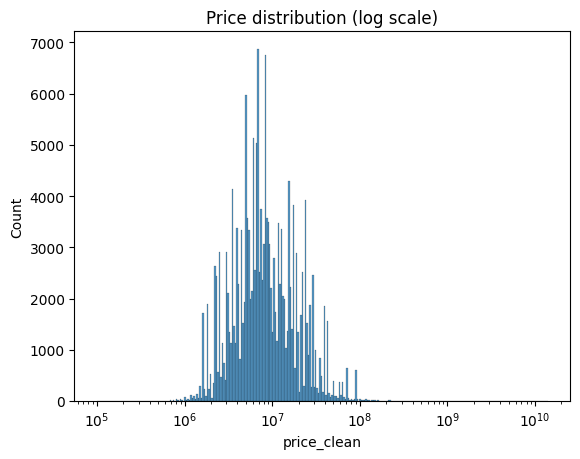

In [40]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.histplot(df["price_clean"], log_scale=True) 
plt.title("Price distribution (log scale)")
plt.show() 

### price vs carpet area 
#### A scatter plot of Price versus Carpet Area displayed on a logarithmic scale. It reveals a dense concentration of properties clustered at smaller carpet areas with prices spanning widely from $10^5$ to $10^9$. A few outlier properties extend toward larger carpet areas up to 700000

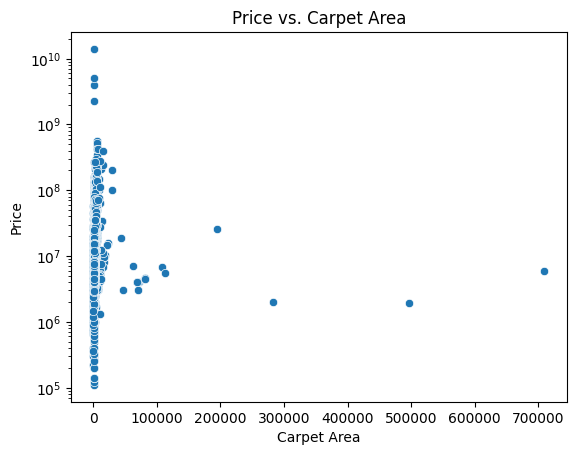

In [41]:
sns.scatterplot(x=df["carpet_area_sqft"], y=df["price_clean"])
plt.yscale("log")
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet Area")
plt.ylabel("Price")
plt.show()

### Average Price by Top-15 Locations
#### A horizontal bar chart illustrating the average property price across the top 15 locations. Mumbai leads significantly by a large margin with an average price exceeding $3.3 \times 10^7$, followed by Gurgaon and Siliguri

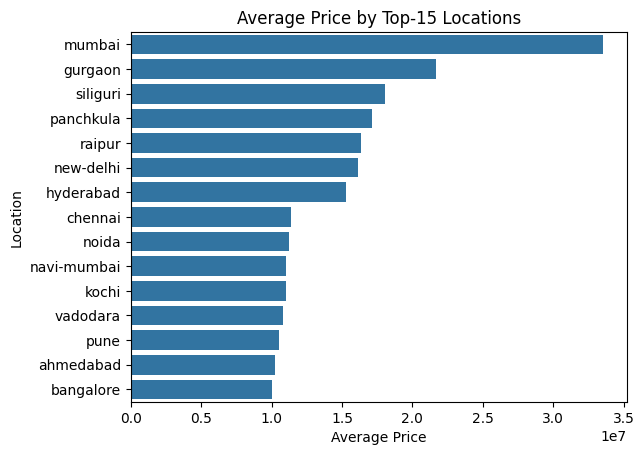

In [42]:
top_15_locations=df.groupby("location_top")["price_clean"].mean().nlargest(15).reset_index()

sns.barplot(data=top_15_locations, x="price_clean", y="location_top")
plt.title("Average Price by Top-15 Locations")
plt.xlabel("Average Price")
plt.ylabel("Location")
plt.show()

### Price Distribution by Furnishing Status
#### Box plots comparing price distributions (on a log scale) across different furnishing statuses (Unfurnished, Semi-Furnished, Furnished, and Unknown). The median prices across categories remain relatively stable near $10^7$, with Semi-Furnished properties exhibiting a slightly higher median and upper quartile range, alongside numerous upper-bound outliers across all categories.

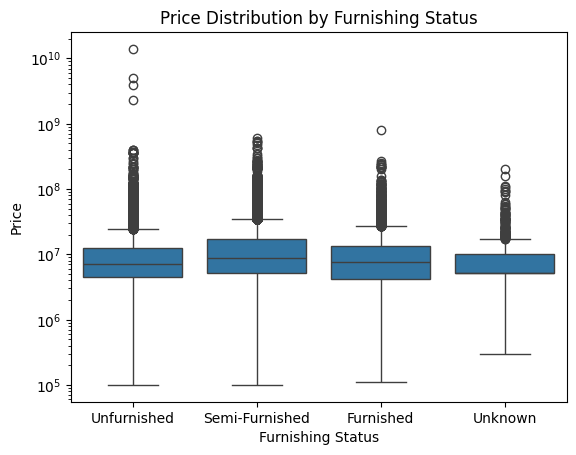

In [43]:
sns.boxplot(data=df, x="Furnishing", y="price_clean")
plt.yscale("log")
plt.title("Price Distribution by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price")
plt.show()

### Price Distribution by Number of Bathrooms
#### Box plots demonstrating a clear positive correlation between the number of bathrooms and property prices. As the bathroom count increases from 1 to 10, both the median and interquartile ranges of prices shift steadily upward on the logarithmic scale, reflecting increased property size and luxury value.

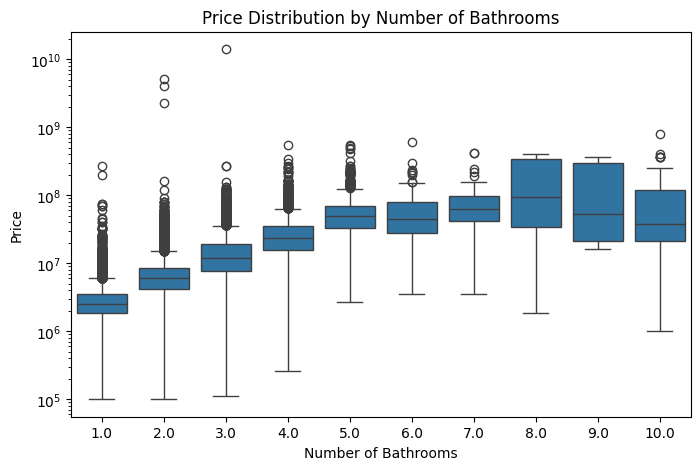

In [44]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Bathroom", y="price_clean")
plt.yscale("log")

plt.title("Price Distribution by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")
plt.show()

# Feature Selection & Engineering

### removing outliers(below the 1st or above the 99th percentile) from price per sqft

In [45]:
df["price_per_sqft"]=(
    df["price_clean"] / df["carpet_area_sqft"]
)

In [46]:
lower_bound=df["price_per_sqft"].quantile(0.01)
upper_bound=df["price_per_sqft"].quantile(0.99)

df=df[
    (df["price_per_sqft"] >= lower_bound) &
    (df["price_per_sqft"] <= upper_bound)
].copy()

In [47]:
df.shape

(95263, 12)

In [48]:
df.head(20)

,Amount(in rupees),Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,price_clean,location_top,carpet_area_sqft,floor_num,price_per_sqft
0,42 Lac,Resale,Unfurnished,Unknown,1.0,2.0,Unknown,4200000.0,thane,500.0,10.0,8400.000000
1,98 Lac,Resale,Semi-Furnished,East,2.0,2.0,Freehold,9800000.0,thane,473.0,3.0,20718.816068
2,1.40 Cr,Resale,Unfurnished,East,2.0,2.0,Freehold,14000000.0,thane,779.0,10.0,17971.758665
3,25 Lac,Resale,Unfurnished,Unknown,1.0,1.0,Unknown,2500000.0,thane,530.0,1.0,4716.981132
4,1.60 Cr,Resale,Unfurnished,West,2.0,2.0,Co-operative Society,16000000.0,thane,635.0,20.0,25196.850394
6,16.5 Lac,Resale,Unfurnished,Unknown,1.0,2.0,Unknown,1650000.0,thane,550.0,4.0,3000.000000
9,1.60 Cr,Resale,Unfurnished,East,3.0,1.0,Freehold,16000000.0,thane,900.0,3.0,17777.777778
10,1.40 Cr,Resale,Semi-Furnished,Unknown,2.0,2.0,Co-operative Society,14000000.0,thane,950.0,6.0,14736.842105
13,4.25 Cr,Resale,Semi-Furnished,East,4.0,1.0,Freehold,42500000.0,thane,1820.0,18.0,23351.648352
15,90 Lac,New Property,Unfurnished,North - East,2.0,1.0,Freehold,9000000.0,thane,675.0,10.0,13333.333333


# Build a Pipeline & Train 

In [49]:
from sklearn.model_selection import train_test_split 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.linear_model import LinearRegression 

In [50]:
numeric_features = ["carpet_area_sqft", "floor_num", "Bathroom", "Balcony"] 
categorical_features = ["location_top", "Furnishing", "Transaction", "Ownership", "facing"] 

In [51]:
preprocessor = ColumnTransformer([ 
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())]), numeric_features), 
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), 
    ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features), ]) 

In [52]:
X = df[numeric_features + categorical_features] 
y = df["price_clean"] 

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
linear_model=Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [55]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [56]:
y_pred=linear_model.predict(X_test)

In [57]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae=mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2=r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 4156373.6446673856
RMSE: 6662528.054056648
R²: 0.7492227936904359


In [58]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200,random_state=42))
    ]
)

In [59]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [60]:
rf_pred=rf_model.predict(X_test)

mae_rf=mean_absolute_error(y_test, rf_pred)
rmse_rf=np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf=r2_score(y_test, rf_pred)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

MAE: 959527.029364476
RMSE: 3433784.0518256687
R²: 0.9333874718235587


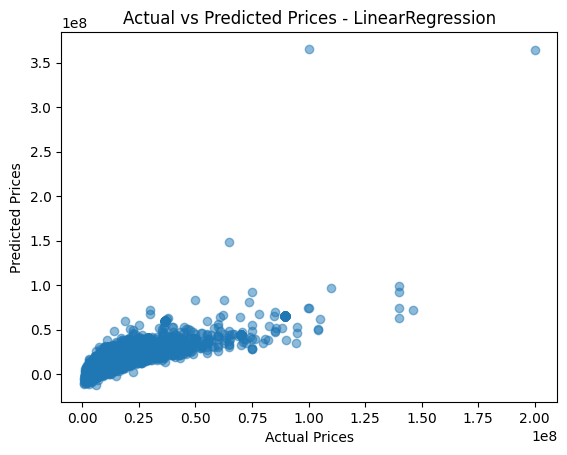

In [61]:
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices - LinearRegression")

plt.show()

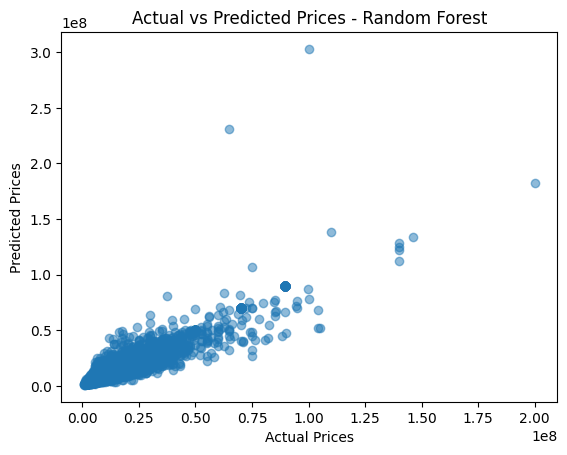

In [62]:
plt.scatter(y_test, rf_pred, alpha=0.5)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices - Random Forest")

plt.show()

In [63]:
comparison=pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R²": [r2, r2_rf]
})

In [64]:
comparison

,Model,MAE,RMSE,R²
0,Linear Regression,4.156374e+06,6.662528e+06,0.749223
1,Random Forest,9.595270e+05,3.433784e+06,0.933387


### the random forrest model is performing better in every aspect, which means it can captures the features relationships and patterns better than the linear regression. we will choose the random forest model as the winner model because it can provide better predictions 

# Export the Model 

In [68]:
import joblib 
joblib.dump(rf_model, "house_price.pkl", compress=9) 

['house_price.pkl']

In [69]:
loaded = joblib.load("house_price.pkl") 
sample = X_test.iloc[[0]] 
print("Reloaded prediction:", loaded.predict(sample)) 

Reloaded prediction: [4564250.]


In [70]:
import json 
json.dump(sorted(df["location_top"].unique().tolist()), open("locations.json", "w")) 